# Biến đổi cosin rời rạc sửa đổi (MDCT)

## Giới thiệu

Trong xử lý âm thanh và tiếng nói, chúng ta thường cần chia tín hiệu thành các đoạn ngắn hoặc các cửa sổ ([windows](../Representations/Windowing.ipynb)), bởi vì:

-   Tín hiệu âm thanh biến đổi tương đối chậm theo thời gian, do đó việc phân đoạn tín hiệu thành các cửa sổ ngắn cho phép giả định tín hiệu là dừng (stationary) - đây là điều kiện tiên quyết của nhiều phương pháp hiệu quả như [phân tích phổ (spectral analysis)](../Representations/Spectrogram_and_the_STFT.ipynb).
-   Phân tích trong miền biến đổi (ví dụ như phân tích phổ) đòi hỏi chúng ta phải biến đổi toàn bộ tín hiệu trong một thao tác duy nhất. Điều này yêu cầu phải nhận được toàn bộ tín hiệu trước khi có thể bắt đầu xử lý. Trong viễn thông, điều này có nghĩa là chúng ta phải đợi một câu nói kết thúc trước khi bắt đầu gửi đi, và do đó việc tái cấu trúc câu nói ở đầu thu cũng phải đợi cho đến khi toàn bộ câu kết thúc, gây ra một độ trễ đáng kể trong giao tiếp.

Trong các tình huống thực tế, chúng ta do đó luôn áp dụng phép chia cửa sổ trước khi xử lý.

Tuy nhiên, việc áp dụng xử lý phổ, chẳng hạn như xử lý trong miền [STFT](../Representations/Spectrogram_and_the_STFT.ipynb), trong các ứng dụng viễn thông có một nhược điểm lớn. Chúng ta cần các cửa sổ **gối chồng** (overlapping) để cho phép **tái cấu trúc hoàn hảo** (perfect reconstruction), nghĩa là chúng ta có thể khôi phục lại hoàn hảo tín hiệu gốc từ tín hiệu đã chia cửa sổ. Mặc dù vậy, sự gối chồng đồng nghĩa với việc các cửa sổ liên tiếp chia sẻ thông tin từ cùng các mẫu tín hiệu (xem hình bên phải). Do đó, cùng một thông tin phải được mã hóa trong **cả hai cửa sổ**, dẫn đến sự kém hiệu quả. Khi mã hóa tín hiệu, mục tiêu của chúng ta là nén thông tin thành ít bit nhất có thể, nhưng nếu mã hóa một phần thông tin hai lần, chúng ta sẽ làm tăng lượng thông tin cần mã hóa. Miền STFT do đó gây ra hiện tượng **mã hóa dư thừa** (over-coding), nơi mà trong thực tế, hai luồng bit khác nhau có thể biểu diễn cùng một tín hiệu đầu ra.

**Biến đổi cosin rời rạc sửa đổi** (Modified Discrete Cosine Transform - MDCT) là một giải pháp cho vấn đề mã hóa dư thừa này. MDCT sử dụng các toán tử chiếu (projection-operators) tại các vùng gối chồng sao cho thông tin trong các cửa sổ liên tiếp trực giao với nhau. Vì thông tin được bảo toàn hoàn hảo, lượng thông tin không bị tăng lên cũng không bị giảm đi, và ta gọi toán tử này là **lấy mẫu tới hạn** (critically sampled).

MDCT do đó cung cấp một biểu diễn thời gian - tần số của tín hiệu đầu vào, cho phép phân tích và xử lý sự biến đổi theo thời gian của các thành phần tần số. Nó chia sẻ hầu hết các đặc tính có lợi của STFT: tín hiệu được xử lý trong miền MDCT vẫn liên tục trong miền thời gian và chúng ta có thể sử dụng các thuật toán dựa trên FFT để triển khai hiệu quả. Có lẽ sự khác biệt lớn nhất giữa STFT và MDCT (ngoài việc lấy mẫu tới hạn của MDCT) là trong khi STFT là một biểu diễn giá trị phức (complex-valued), MDCT lại là một biểu diễn giá trị thực (real-valued) khi tín hiệu đầu vào là giá trị thực.

Nhờ những đặc tính có lợi này của MDCT, nó là phép biến đổi thời gian - tần số được sử dụng phổ biến nhất trong mã hóa âm thanh và tiếng nói, và được áp dụng trong các bộ codec tiêu chuẩn như MPEG USAC, 3GPP EVS và Bluetooth LC3.

![ola2-1.png](attachments/148295002.png)


## Tóm tắt thuật toán

MDCT hoạt động dựa trên việc lấy phần đối xứng và phản đối xứng của tín hiệu tại vùng gối chồng, sao cho phần đối xứng đi vào cửa sổ này còn phần phản đối xứng đi vào cửa sổ kia. Chúng ta tiếp tục chia cửa sổ (window) cho các phần đối xứng và phản đối xứng đó sao cho chúng hội tụ mượt mà về không ở các cạnh biên. Các cửa sổ liên tiếp do đó trực giao với nhau tại vùng gối chồng, giúp thông tin được phân chia chính xác làm đôi, nhờ đó ta đạt được sự tái cấu trúc hoàn hảo và lấy mẫu tới hạn. Hơn nữa, vì các đoạn tín hiệu đã được chia cửa sổ, chúng ta không gặp phải bất kỳ vấn đề nào với các điểm bất liên tục.

Thứ hai, chúng ta thực hiện phép biến đổi cosin rời rạc (DCT) trên tín hiệu đã chia cửa sổ (= của phép chiếu trực giao). Tuy nhiên, phép biến đổi DCT thông thường phải được tinh chỉnh sao cho pha và tính đối xứng của nó khớp với phần đối xứng và phản đối xứng của tín hiệu. Do đó phép biến đổi này có tên gọi là **DCT sửa đổi (MDCT)**. Việc khớp các tính chất đối xứng này chỉ khả thi thông qua sự sửa đổi này của DCT và không thể tổng quát hóa cho phép biến đổi Fourier rời rạc (DFT).

Phần đối xứng (hoặc phản đối xứng) của tín hiệu khi đó "trông giống như tín hiệu" có sẵn tính đối xứng này. Nói cách khác, chúng ta đưa vào một **sự sai lệch** so với tín hiệu gốc, và sự sai lệch này được gọi là thành phần **méo dạng miền thời gian** (time-domain aliasing), vì nó tương tự như các hiệu ứng méo dạng xảy ra với DFT. Tuy nhiên, trong quá trình tái cấu trúc, chúng ta cộng phần đối xứng và phản đối xứng lại với nhau, khiến chúng tự triệt tiêu lẫn nhau; hiện tượng này được gọi là **triệt tiêu méo dạng miền thời gian (TDAC)**. TDAC tương đương với phép chiếu trực giao làm nền tảng cho MDCT, và do đó là một đặc tính trung tâm của MDCT.


## Giải thích trực quan

Chúng ta bắt đầu với một mẫu âm thanh và trích xuất một đoạn từ đó.


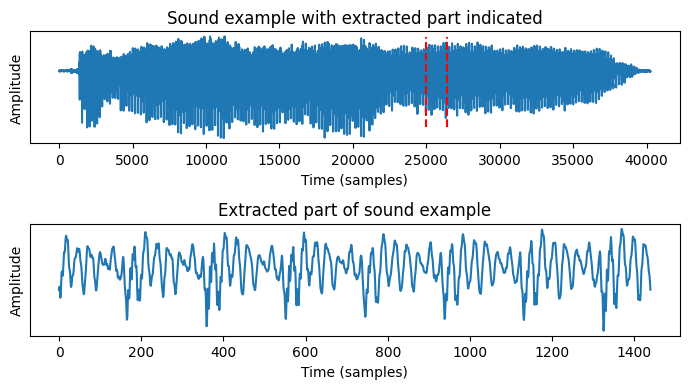

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import IPython.display as ipd 

sample_rate, data = scipy.io.wavfile.read('sounds/soundexample.wav')

window_length_ms = 30
window_length = (sample_rate*window_length_ms)//1000
window_step = window_length//2
window_count = 5

ix = np.arange(25000,25000+window_step*(window_count+1))

plt.figure(figsize=(7,4))

plt.subplot(211)
plt.title('Sound example with extracted part indicated')
plt.plot(data)
plt.plot([ix[0],ix[0]],[-10000,6000],'r--')
plt.plot([ix[-1],ix[-1]],[-10000,6000],'r--')
plt.ylabel('Amplitude')
plt.xlabel('Time (samples)')
plt.yticks([])

plt.subplot(212)
plt.title('Extracted part of sound example')
plt.plot(data[ix])
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.yticks([])

plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data,rate=sample_rate))

data = data[ix]

Chúng ta có thể chia cửa sổ đoạn tín hiệu này bằng các cửa sổ chữ nhật (nghĩa là không dùng hàm cửa sổ chuyên dụng).
Các vùng gối chồng giữa các cửa sổ là khu vực nằm giữa các đường đứt nét màu đen.


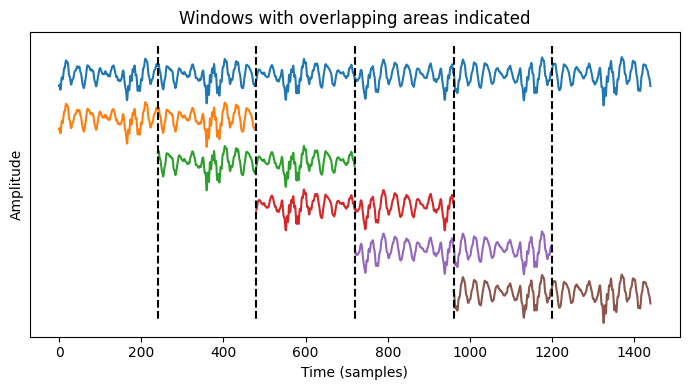

In [50]:
plt.figure(figsize=(7,4))
plt.plot(data)
for win_idx in np.arange(window_count,dtype=np.int32):
    start_idx = window_step*win_idx
    end_idx = start_idx + window_length
    idx = np.arange(start_idx,end_idx,dtype = np.int32)
    plt.plot(idx, data[idx]-12000*(win_idx+1))

for win_idx in np.arange(1,window_count+1):
    plt.plot(win_idx*window_step*np.array([1,1]),[8000, -12000*(window_count+.6)],'k--')

plt.ylabel('Amplitude')
plt.xlabel('Time (samples)')
plt.title('Windows with overlapping areas indicated')
plt.yticks([])
plt.tight_layout()

Theo định nghĩa, cùng một tín hiệu sẽ xuất hiện ở mỗi cặp cửa sổ kế tiếp nhau. Trong các ứng dụng truyền dẫn, đây là một vấn đề vì cùng một thông tin sẽ phải truyền đi hai lần.

Sự dư thừa mã hóa (overcoding) này có thể tránh được bằng cách chia tín hiệu thành hai phần trực giao trong các vùng gối chồng. Chúng ta có thể làm điều này bằng cách chia tín hiệu thành phần đối xứng và phần phản đối xứng. Tổng của hai phần này sau đó vẫn cộng lại bằng tín hiệu gốc.


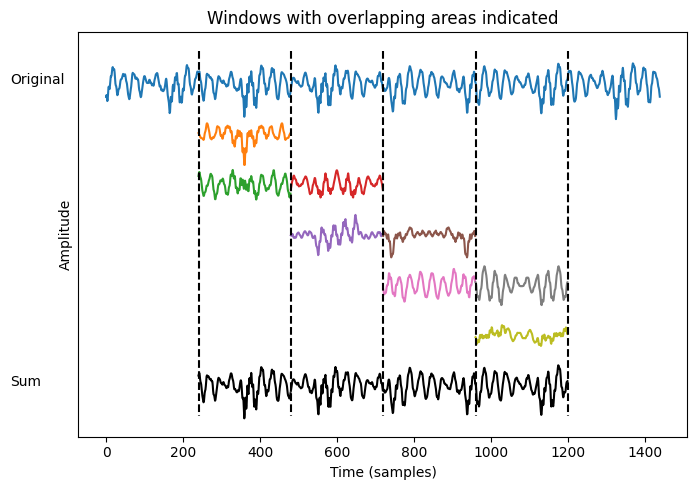

In [74]:
plt.figure(figsize=(7,5))
plt.plot(data)

def Psplit(x):
    return .5*(x+np.flipud(x)), .5*(x-np.flipud(x))

for win_idx in np.arange(1,window_count):
    start_idx = window_step*win_idx
    end_idx = start_idx + window_step
    idx = np.arange(start_idx,end_idx,dtype = np.int32)
    s,a = Psplit(data[idx])
    plt.plot(idx, s-12000*(win_idx))
    plt.plot(idx, a-12000*(win_idx+1))
    plt.plot(idx, a+s -12000*(window_count+1),'k')

for win_idx in np.arange(1,window_count+1):
    plt.plot(win_idx*window_step*np.array([1,1]),[8000, -12000*(window_count+1.6)],'k--')

plt.ylabel('Amplitude')
plt.xlabel('Time (samples)')
plt.title('Windows with overlapping areas indicated')
plt.yticks([])

plt.text(-250,0,'Original')
plt.text(-250,-12000*(window_count+1),'Sum')
plt.tight_layout()

Phép phân tách này không sử dụng bất kỳ hàm cửa sổ nào và do đó ta thấy đôi khi có những điểm bất liên tục lớn ở tâm của cửa sổ. Các điểm bất liên tục tương tự cũng sẽ xảy ra ở các cạnh cửa sổ, nếu các cửa sổ bị sửa đổi trước khi tái cấu trúc.

Thật ngạc nhiên, việc phân tách thành các phần này có thể được kết hợp trực tiếp với phép chia cửa sổ (windowing), cả trước và sau khi xử lý. Việc tái cấu trúc hoàn hảo (perfect reconstruction) của tín hiệu vẫn hoạt động bình thường.


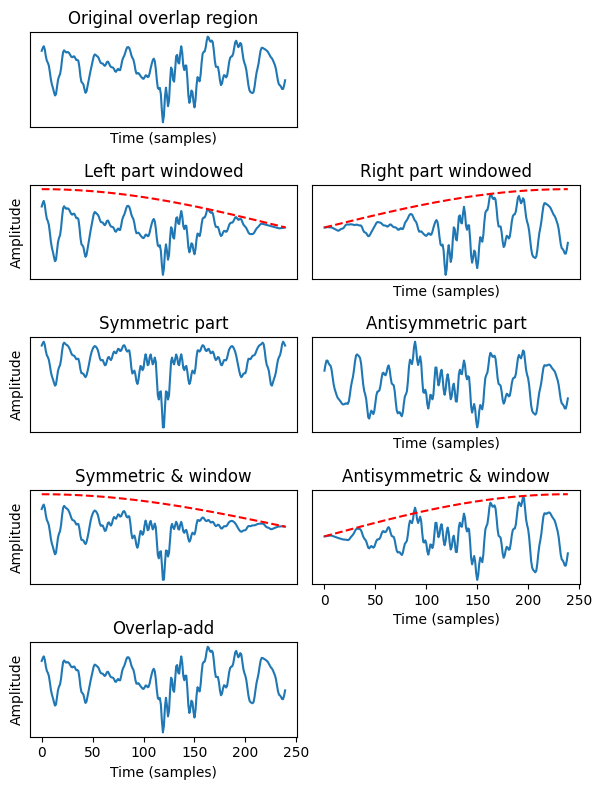

In [104]:
lwin = np.cos(np.pi*np.arange(.5,window_step)/(2*window_step))
rwin = np.flipud(lwin)

datawin = data[window_step:2*window_step]

plt.figure(figsize=(6,8))
plt.subplot(521)
plt.plot(datawin)
plt.xlabel('Time (samples)')
plt.title('Original overlap region')
plt.yticks([])
plt.xticks([])

plt.subplot(523)
plt.plot(datawin*lwin)
plt.plot(lwin*np.max(datawin),'r--')
plt.ylabel('Amplitude')
plt.title('Left part windowed')
plt.yticks([])
plt.xticks([])

plt.subplot(524)
plt.plot(datawin*rwin)
plt.plot(rwin*np.max(datawin),'r--')
plt.xlabel('Time (samples)')
plt.title('Right part windowed')
plt.yticks([])
plt.xticks([])

plt.subplot(525)
plt.plot(datawin*lwin + np.flipud(datawin*lwin))
plt.ylabel('Amplitude')
plt.title('Symmetric part')
plt.yticks([])
plt.xticks([])

plt.subplot(526)
plt.plot(datawin*rwin - np.flipud(datawin*rwin))
plt.xlabel('Time (samples)')
plt.title('Antisymmetric part')
plt.yticks([])
plt.xticks([])

plt.subplot(527)
plt.plot(lwin*(datawin*lwin + np.flipud(datawin*lwin)))
plt.plot(lwin*np.max(datawin),'r--')
plt.ylabel('Amplitude')
plt.title('Symmetric & window')
plt.yticks([])
plt.xticks([])

plt.subplot(528)
plt.plot(rwin*(datawin*rwin - np.flipud(datawin*rwin)))
plt.plot(rwin*np.max(datawin),'r--')
plt.xlabel('Time (samples)')
plt.title('Antisymmetric & window')
plt.yticks([])

plt.subplot(529)
plt.plot(lwin*(datawin*lwin + np.flipud(datawin*lwin)) + rwin*(datawin*rwin - np.flipud(datawin*rwin)))
plt.ylabel('Amplitude')
plt.xlabel('Time (samples)')
plt.title('Overlap-add')
plt.yticks([])

plt.tight_layout()
plt.show()

Khi áp dụng cùng một quy trình cho tất cả các cửa sổ, chúng ta có thể tái cấu trúc lại toàn bộ tín hiệu.


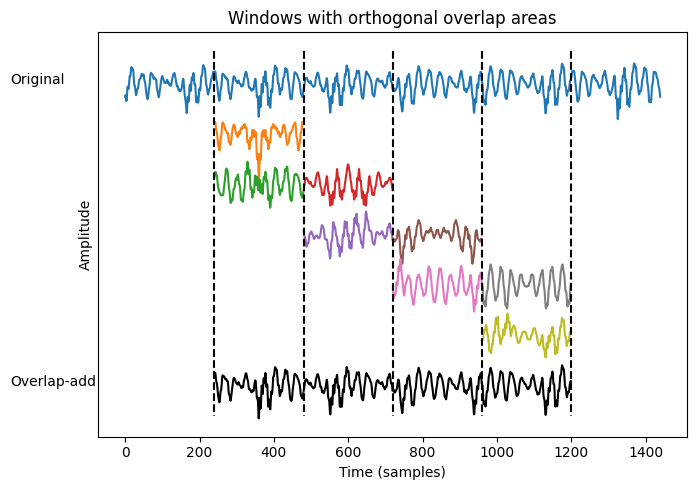

In [107]:
hwin = np.cos(np.pi*np.arange(.5,window_step)/(2*window_step))

plt.figure(figsize=(7,5))
plt.plot(data)

def winsplit(x,hwin):
    fwin = np.flipud(hwin)
    l = hwin*x
    r = fwin*x
    return (l+np.flipud(l)), (r-np.flipud(r))

def winmerge(s,a,hwin):
    fwin = np.flipud(hwin)
    return s*hwin + a*fwin

for win_idx in np.arange(1,window_count):
    start_idx = window_step*win_idx
    end_idx = start_idx + window_step
    idx = np.arange(start_idx,end_idx,dtype = np.int32)
    s,a = winsplit(data[idx],hwin)
    plt.plot(idx, s-12000*(win_idx))
    plt.plot(idx, a-12000*(win_idx+1))
    plt.plot(idx, winmerge(s,a,hwin) -12000*(window_count+1),'k')

for win_idx in np.arange(1,window_count+1):
    plt.plot(win_idx*window_step*np.array([1,1]),[8000, -12000*(window_count+1.6)],'k--')

plt.ylabel('Amplitude')
plt.xlabel('Time (samples)')
plt.title('Windows with orthogonal overlap areas')
plt.yticks([])

plt.text(-310,0,'Original')
plt.text(-310,-12000*(window_count+1),'Overlap-add')
plt.tight_layout()

Biểu diễn này tương thích với biến đổi cosin rời rạc (DCT), sao cho chúng ta có thể thực hiện DCT cho mỗi cửa sổ với các phần gối chồng trực giao. Sau đó, chúng ta thu được một biểu diễn thời gian - tần số của tín hiệu, trong đó mỗi khung là độc lập với tất cả các khung khác.


## Định nghĩa toán học

Giả sử $x$ là một vector $N\times1$ biểu diễn vùng gối chồng được chia sẻ
bởi hai cửa sổ liên tiếp, chẳng hạn như khu vực giữa 15 và 30 ms trong
hình phía trên bên phải. Nhiệm vụ của chúng ta là thiết kế một ma trận chiếu $P$ có
kích thước $N\times N$, sao cho chúng ta có thể phân tách $x$ thành hai phần trực giao:

$$ \begin{cases} x_L &= Px\\ x_R &= P_0x \end{cases} $$

trong đó $P_{0}$ là nhân (kernel) của $P$ và do đó $ P_0 P^T = 0,
$ nhờ đó ta có thể tái cấu trúc $x$ dưới dạng:

$$ P^T x_L+P_0^Tx_R = P^T P x + P_0^T P_0 x = (P^T P + P_0^T P_0)x =
x, $$

vì $ P^T P + P_0^T P_0 = I $ theo định nghĩa.

Các vector $x_{L}$ và $x_{R}$, tương ứng với các
cửa sổ bên trái và bên phải, do đó đều có độ dài $N/2$ và mỗi
vector chứa chính xác một nửa thông tin của $x$.

Mặc dù đây là một giải pháp toán học gọn gàng, nó lại không thực tế
vì sau khi xử lý, tín hiệu tái cấu trúc có thể xuất hiện
các điểm bất liên tục. Ví dụ, giả sử chúng ta định nghĩa $P$ là toán tử
trích xuất phần đối xứng của $x$, tức là $ P = [I,
J]\sqrt{1/2}, $ trong đó $I$ là ma trận đơn vị $(N/2)\times(N/2)$ và
$J$ là ma trận đảo chiều trái-phải (đường chéo phụ) của nó. Nhân của
phép chiếu khi đó là $ P_0 = [I, -J]\sqrt{1/2}. $ Nếu chúng ta thực hiện một thay đổi nhỏ
đối với tín hiệu dưới dạng $ x_L':=x_L+d, $ thì tín hiệu tái cấu trúc là $
x':=P^Tx_L+P^Td+P_0^Tx_R=x+P^Td, $ nghĩa là tín hiệu gốc bị
thay đổi một lượng $P^Td$. Tuy nhiên, thành phần này không
triệt tiêu về không ở các biên ranh giới, làm cho tín hiệu sau xử lý không
được liên tục. Cụ thể, xét ví dụ một vector sai lệch $ d =
[1,\,1,\,\dotsc,\,1]^T, $ ta thu được $ P^Td =
\sqrt{1/2}[1,\,1,\,\dotsc,\,1]^T, $ vốn rõ ràng khác không
ở cả hai đầu của vector.

Nguyên nhân của vấn đề này là định nghĩa trên chưa bao gồm hàm
cửa sổ (windowing function). Hãy nhớ lại rằng phép chia cửa sổ thực chất là phép nhân
từng mẫu của tín hiệu với một hàm cửa sổ. Trong ký hiệu ma trận,
chúng ta có thể thực hiện điều này bằng cách nhân tín hiệu đầu vào $x$ với
một ma trận đường chéo $W$, nơi các phần tử trên đường chéo chính
tương ứng với hàm cửa sổ. Tín hiệu sau khi chia cửa sổ sẽ là $Wx$. Phép chiếu
đối xứng $P$ sau đó có thể được áp dụng trên tín hiệu đã chia cửa sổ sao cho các
tín hiệu trái và phải sau chia cửa sổ là:

$$ 
\begin{cases} x_L &= PWx := P'x\\ x_R &= P_0'x = P_0JWJx
\end{cases} 
$$

trong đó $P_{0}'$ là nhân của $P'$, và $JWJ$ đơn giản là
phần đảo chiều của cửa sổ (nếu $W$ là phần bên trái tăng dần
của cửa sổ, thì $JWJ$ là phần bên phải giảm dần của cửa sổ). Lưu ý rằng
mối quan hệ giữa hai nhân $ P_0'=P_0JWJ $
chỉ áp dụng cho toán tử đối xứng được định nghĩa ở trên, chứ không áp dụng cho trường hợp tổng quát.
Dù thế nào, định nghĩa trên lúc này đã bao gồm cả phép chia cửa sổ và
phép chiếu trực chuẩn, nhờ đó các đặc tính có lợi như
tái cấu trúc hoàn hảo và lấy mẫu tới hạn được giữ lại, nhưng lúc này
tín hiệu cũng chuyển mượt mà về không ở các cạnh biên, vì chúng ta
đã áp dụng một hàm cửa sổ.

Như vậy, ở phần trên chúng ta đã phát triển một phép toán chia cửa sổ có
các đặc tính cần thiết. Tuy nhiên, mục tiêu của chúng ta là thu được một phép biến đổi
thời gian - tần số của tín hiệu, do đó chúng ta vẫn còn thiếu phép biến đổi này.

Mục tiêu của chúng ta là tìm ra một biểu diễn phổ của tín hiệu đầu vào
đã chia cửa sổ. Điều quan trọng cần lưu ý là ở trên chúng ta đã nghiên cứu các
đặc tính tại phần gối chồng, nơi ta thực hiện phép chiếu trực chuẩn của
phần gối chồng để thu được phần bên trái của cửa sổ hiện tại $x_{L}$ và
phần bên phải của cửa sổ đứng trước $x_{R}$. Để tránh nhầm lẫn,
ở đây chúng ta cần đưa vào chỉ số khung hình (frame indices), sao cho các phần
gối chồng lần lượt là $x_{L,k}$ và $x_{R,k-1}$.
Tuy nhiên, biểu diễn phổ phải bắt nguồn từ một khung hình duy nhất,
nghĩa là chúng ta định nghĩa khung hình $k$ là:

$$ \widehat x_k := \begin{bmatrix}x_{L,k} \ x_{R,k}
\end{bmatrix}. $$

Để thu được phổ của $ \widehat x_k $, chúng ta nhân nó
với một ma trận biến đổi thời gian - tần số $D$, sao cho biểu diễn
tần số thu được là $ y_k=D\widehat x_k $ và biểu diễn tái cấu trúc
là $ \widehat x_k = D^T y_k, $ với giả định $D$
là ma trận trực giao (như các ma trận biến đổi thời gian - tần số thông thường).

Về nguyên tắc, ma trận biến đổi $D$ có thể là bất kỳ phép biến đổi thời gian -
tần số nào (DFT, DCT-I, DCT-II, DST-I, v.v.), nhưng chúng ta cần chọn một
phép biến đổi cụ thể. Để đánh giá mức độ hợp lý của một lựa chọn cụ thể, chúng ta
cần kiểm tra xem phép biến đổi đó hoạt động tốt như thế nào khi kết hợp với các
phép chiếu trực giao trước đó. Cụ thể, hãy thế định nghĩa của các phần trái
và phải vào phương trình trên để thu được:

$$ 
\widehat x_k := \begin{bmatrix}x_{L,k} \\ x_{R,k}
\end{bmatrix} = \begin{bmatrix}PWx_k \\ P_0JWJx_{k+1}
\end{bmatrix} = \begin{bmatrix}PW & P_0JWJ \end{bmatrix}
\begin{bmatrix}x_k \\ x_{k+1} \end{bmatrix} := \hat P
\begin{bmatrix}x_k \\ x_{k+1} \end{bmatrix}. 
$$

Như vậy, sự kết hợp của phép chia cửa sổ + phép chiếu + biến đổi phổ là
$y_k=D\hat P \begin{bmatrix}x_k \\ x_{k+1} \end{bmatrix} = M \begin{bmatrix}x_k \\ x_{k+1} \end{bmatrix}. $
Để đánh giá mức độ hợp lý của một phép biến đổi thời gian - tần số cụ thể,
chúng ta phải nghiên cứu các hàm cơ sở (basis functions) của ma trận $M$. Bằng cách
duyệt qua mọi tùy chọn khả thi, ta dễ dàng thấy rằng phần mở rộng chẵn/lẻ
ẩn của các phép biến đổi DCT chỉ khớp với các phép chiếu đối xứng/phản đối xứng đối
với DCT-III. Đối với các tùy chọn khác, chúng ta luôn gặp các điểm bất liên tục
trong các hàm cơ sở.

Nói một cách trực quan, chúng ta muốn các hàm cơ sở "trông giống như"
các tín hiệu thực tế có khả năng xuất hiện trong một hệ vật lý tự nhiên.
Trực quan hơn, các hàm cơ sở "đẹp đẽ" như vậy sẽ ít bị rò rỉ
phổ (spectral leakage) giữa các khoảng tần số (spectral bins), do đó mô tả
chính xác hơn các đặc tính phổ của tín hiệu đầu vào.
{cite}`backstrom2017speech`

Xem thêm tại <https://github.com/audiolabs/lapped-transforms>

## Tài liệu tham khảo
